# Estatística 1 - Aula prática 5_1 em Python

## UNIDADE 5: Testes nao Parametricos  

### Seção 5.1 One-Sample Wilcoxon Signed Rank Test

By Jose P. Leitão

In [14]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binom

In [2]:
# Carregar o arquivo data_rats.csv
df = pd.read_csv("data_rats.csv")

In [3]:
# mostra um resumo
df.describe()

,weight
count,10.000000
mean,19.220000
std,1.325644
min,17.100000
25%,18.225000
50%,19.050000
75%,20.225000
max,21.100000


In [4]:
# Vamos calcular a mediana
print(f"O valor da mediana é {df['weight'].median()}")

O valor da mediana é 19.05


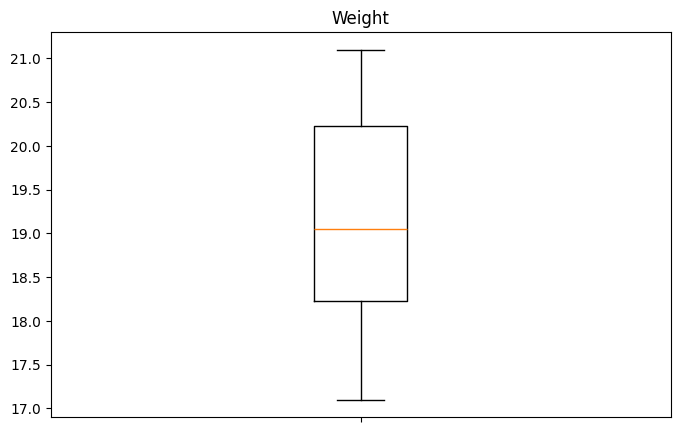

In [5]:
# Gráfico de boxplot

x1 = df['weight'].to_numpy()

fig, ax = plt.subplots(figsize=(8,5))
bplot = ax.boxplot(x1)
ax.axes.set_xticklabels("")
ax.set_title("Weight")
# Grade
#ax.grid(True, color="gray", linestyle="--", linewidth=0.7)

plt.show()

In [ ]:
# Nao temos valores extremos, mas se tivessemos nao haveria 
# problema algum

# Vamos calcular o One-sample Wilcoxon Signed Rank Test e 
# queremos saber se o peso mediano dos ratos difere de 25g
# (teste bicaudal)

# As hipoteses do teste sao:

# H0: peso mediano dos ratos eh estatisticamente igual a 25g
# HA: peso mediano dos ratos nao eh estisticamente igual a 25g


In [9]:

# amostra
x1 = df['weight'].to_numpy()

# mediana hipotética
m0 = 25

# diferenças em relação à mediana hipotética
diff = x1 - m0

# teste de Wilcoxon
stat, p_value = wilcoxon(diff)

print("Estatística:", stat)
print(f"p-valor: {p_value:.6f}")

Estatística: 0.0
p-valor: 0.001953


In [ ]:
# Resultado do teste:
# O p-value do teste eh 0,001953, que eh menor que o nivel de 
# significancia 0.05. Podemos rejeitar a hipotese nula e 
# concluir que o peso mediano dos ratos eh estatisticamente
# diferente de 25g com um p-value de p = 0,001953.
# O intervalo de confianca com 95% esta entre 18,10 e 20,15

# Se desejamos testar se o peso mediano dos ratos eh inferior 
# a 25g (que eh um teste unicaudal):
# As hipoteses do teste sao:

# H0: o peso mediano dos ratos eh maior igual que 25g
# HA: o peso mediano dos ratos nao eh maior igual que 25g

In [15]:
def ci_mediana_exato(x, alpha=0.05):
    x = np.sort(np.asarray(x))
    n = len(x)

    # Encontrar k usando distribuição binomial
    k = 0
    while binom.cdf(k - 1, n, 0.5) > alpha / 2:
        k += 1

    low = x[k - 1]
    high = x[n - k]
    return low, high

In [17]:
def ci_mediana_bootstrap(x, alpha=0.05, n_boot=10000):
    x = np.asarray(x)
    boots = []

    for _ in range(n_boot):
        sample = np.random.choice(x, size=len(x), replace=True)
        boots.append(np.median(sample))

    low = np.percentile(boots, 100 * alpha/2)
    high = np.percentile(boots, 100 * (1 - alpha/2))
    return low, high

In [18]:
# teste de Wilcoxon
stat, p_value = wilcoxon(diff, alternative='less')
ic_low, ic_high = ci_mediana_bootstrap(x1, alpha=0.05)

print("Estatística:", stat)
print(f"p-valor: {p_value:.6f}")

Estatística: 0.0
p-valor: 0.000977


In [19]:
print(ic_low, ic_high)

18.1 20.45


In [ ]:
# Resultado do teste:
# O p-value do teste eh 0,0009777, que eh menor que o nivel de 
# significancia 0,05. Podemos rejeitar a hipotese nula e 
# concluir que o peso mediano dos ratos nao eh estatisticamente
# maior que 25g, ou seja, eh menor que 25g (nao rejeitamos Ha).
# O intervalo de confiança eh de um valor menor que 20,05, com
# uma mediana de 19,15.

# Se desejamos testar se o peso mediano dos ratos eh superior que 
# 25g (que eh um teste unicaudal):

# As hipoteses do teste sao:

# H0: o peso mediano dos ratos eh menor igual que 25g
# HA: o peso mediano dos ratos nao eh menor igual que 25g

In [13]:
# teste de Wilcoxon
stat, p_value = wilcoxon(diff, alternative='greater')

print("Estatística:", stat)
print(f"p-valor: {p_value:.6f}")

Estatística: 0.0
p-valor: 1.000000


In [ ]:
# Resultado do teste:
# O p-value do teste eh 1,0 , que eh maior que o nivel de 
# significancia 0.05. Portanto, não podemos rejeitar H0. Assim, 
# concluimos que o peso mediano dos ratos eh estatisticamente
# menor que 25g.
# O intervalo de confiança eh de um valor maior que 18,35, com
# uma mediana de 19,15.